# Anomaly Detection Extended execution file

## Old

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.getcwd())

from AD_QAOA_ext import AD_QAOA
from functions import AD_preprocessing as preprocessing
from functions import AD_utilities as utilities
from functions import AD_training as training
from functions import AD_detection as detection

from functions.AD_probabilistic import execute_qaoa_probcover_on_batches_ml


In [2]:
# 0) Config
ALPHA_RANGE  = np.linspace(-0.9, -0.1, 10)
SELECTED_POS = 1

TOPK_STATES  = 5
TIME_SCALE   = 1.0
VALUE_SCALE  = 1.0


Batch mode: legacy
Selected overlap: 2


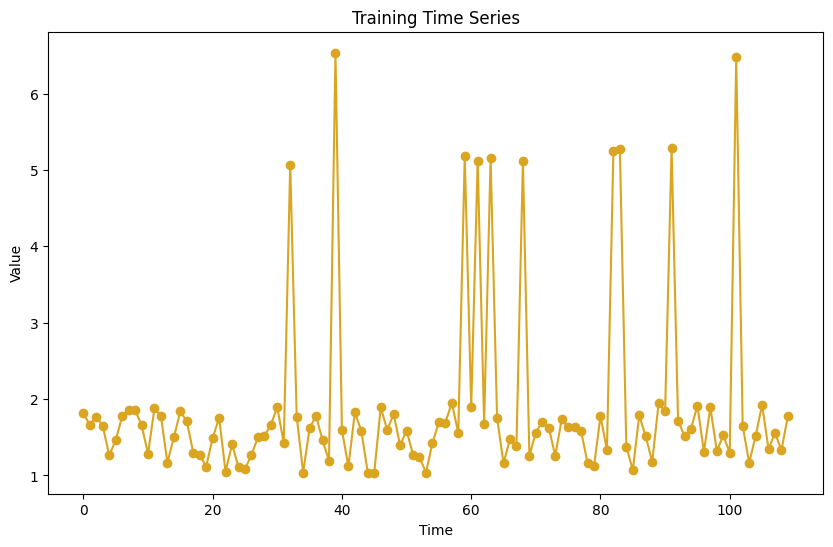


Scaling the TRAIN dataset...


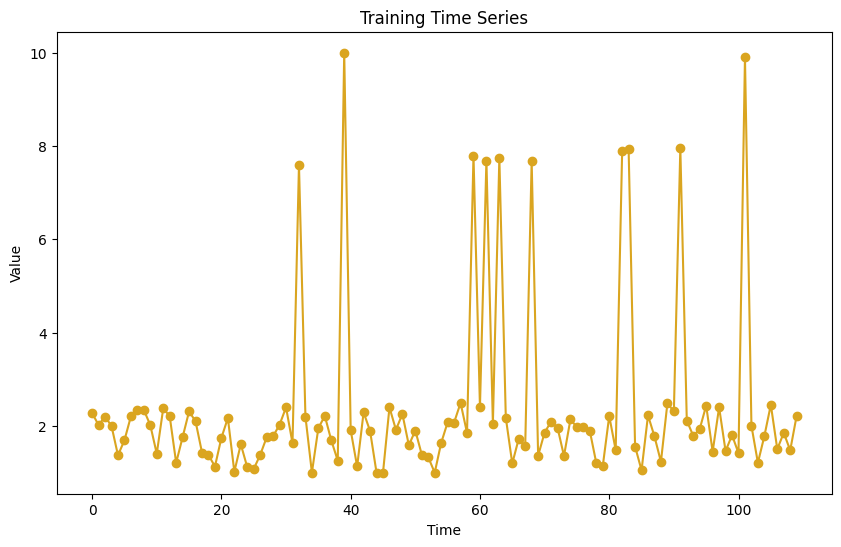

Possible batch sizes: [7, 8, 9]
Best batch size for balanced batches: 7
 Batch 0: size 7
[(0, 2.2772379629129835), (1, 2.021036710995433), (2, 2.202621079729607), (3, 2.000167363811299), (4, 1.373352992801026), (5, 1.6964852824911065), (6, 2.2075389327413255)]
 Batch 1: size 7
[(5, 1.6964852824911065), (6, 2.2075389327413255), (7, 2.333693325477969), (8, 2.345638908658157), (9, 2.0188016031054605), (10, 1.4067385584171026), (11, 2.3799425387952047)]
 Batch 2: size 7
[(10, 1.4067385584171026), (11, 2.3799425387952047), (12, 2.2107938279926316), (13, 1.2129523045195243), (14, 1.7623170115603979), (15, 2.314978875758193), (16, 2.1009137809176672)]
 Batch 3: size 7
[(15, 2.314978875758193), (16, 2.1009137809176672), (17, 1.4316954623568805), (18, 1.3809836872803904), (19, 1.1328416879772836), (20, 1.7477869787011384), (21, 2.1715679388500777)]
 Batch 4: size 7
[(20, 1.7477869787011384), (21, 2.1715679388500777), (22, 1.0206576602764699), (23, 1.6107207355880644), (24, 1.1179684621619794), 

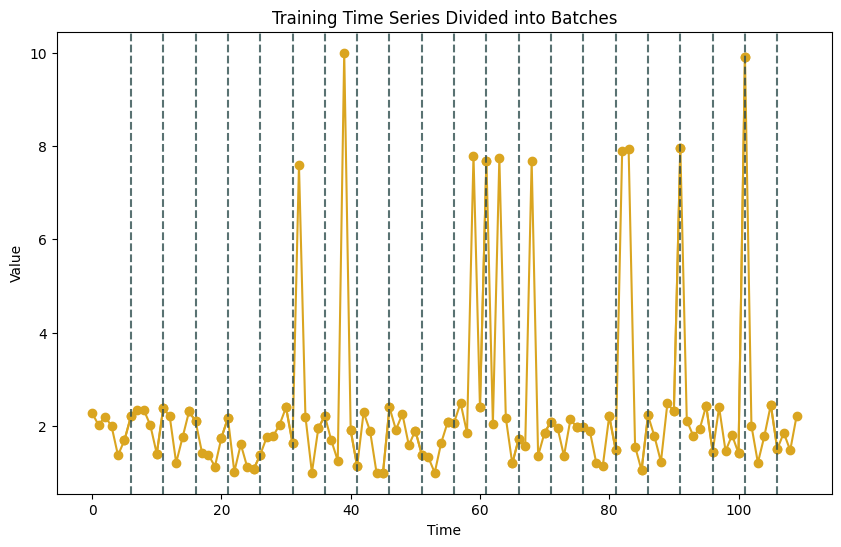


Scaling the TEST dataset...


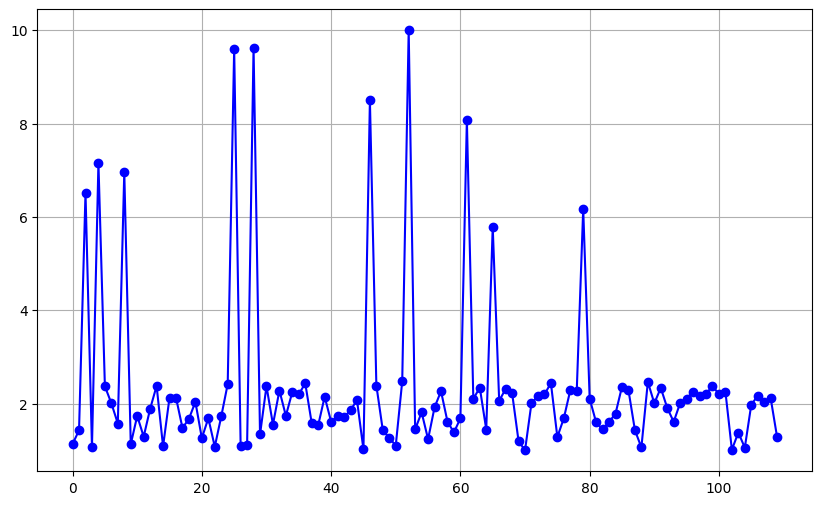

In [3]:
# === ARTIFICIAL DATASET: train/test prep, scaling, batching, plotting ===
import numpy as np
from functions import AD_preprocessing as preprocessing
from functions import AD_utilities as utilities

# 0) Config: scegli "extended" per batch grandi, "legacy" per 7/8/9
BATCH_MODE = "legacy"   # "extended" | "legacy"
overlap    = 2           # un po' più alto per batch grandi (puoi mettere 2)
print("Batch mode:", BATCH_MODE)
print("Selected overlap:", overlap)

# 1) Generate TRAIN
seed = 20  #da 42
np.random.seed(seed)

dataset_train, _ = preprocessing.generate_dataset(
    normal_sample_type='uniform',
    normal_sample_params={'low': 1, 'high': 2, 'size': 100},
    outlier_sample_type='uniform',
    outlier_sample_params={'low': 4, 'high': 7, 'size': 10} #cambiato da 5 a 8
)

utilities.plot_training_time_series(dataset_train)
# print("Train Dataset:", dataset_train)

# 2) Scaling (TRAIN)
print("\nScaling the TRAIN dataset...")
dataset_train_scaled = preprocessing.scale_dataset(dataset_train)
utilities.plot_training_time_series(dataset_train_scaled)

# 3) Batching (TRAIN)
if BATCH_MODE == "extended":
    candidate_bs = [12,14,16]
else:
    candidate_bs = [7, 8, 9]

# Filtra i candidati che entrano nella lunghezza del train
candidate_bs = [b for b in candidate_bs if b <= len(dataset_train_scaled)]
if not candidate_bs:
    candidate_bs = [min(len(dataset_train_scaled),  max(7, 24))]

print("Possible batch sizes:", candidate_bs)

batches, best_batch_size = preprocessing.split_dataset_with_best_batch_size(
    dataset_train_scaled, overlap, candidate_bs
)
print("Best batch size for balanced batches:", best_batch_size)
for i, batch in enumerate(batches):
    print(f" Batch {i}: size {len(batch)}")
    print(batch)

utilities.plot_training_time_series_batches(
    dataset_train_scaled, overlap=overlap, batch_sizes=candidate_bs
)

# 4) Generate TEST (stessa logica)
dataset_test, _ = preprocessing.generate_dataset(
    normal_sample_type='uniform',
    normal_sample_params={'low': 1, 'high': 2, 'size': 100},
    outlier_sample_type='uniform',
    outlier_sample_params={'low': 4, 'high': 7, 'size': 10} #cambiato da 5 a 8
)

# 5) Scaling (TEST) + Plot
print("\nScaling the TEST dataset...")
dataset_test_scaled = preprocessing.scale_dataset(dataset_test)
utilities.plot_test_time_series(dataset_test_scaled)

# >>> Variabili pronte per la pipeline:
# dataset_train_scaled, dataset_test_scaled, batches, best_batch_size

In [4]:
CANDS = ("linear","quadratic","cubic","ma3","ma5","ma7",
         "savgol_w11_p3","spline_s250.0","loess_f0.3")

#CANDS = ("cubic",)
# selezione bilanciata, neutra
GLOBAL_MODEL, GLOBAL_PARAMS = training.select_global_model_for_ad(
    dataset_train_scaled,
    candidates=CANDS,
    w_acc=0.40, w_smooth=0.30, w_floor=0.15, w_cover=0.15,
    rho=1.05, gamma=2.0, target_cov=0.10,
)
print("[GLOBAL AD]", GLOBAL_MODEL, GLOBAL_PARAMS)

# tabella di debug (facoltativa)
dbg = training.debug_model_selection_for_ad(
    dataset_train_scaled, candidates=CANDS,
    w_acc=0.40, w_smooth=0.30, w_floor=0.15, w_cover=0.15,
    rho=1.05, gamma=2.0, target_cov=0.10,
)
print(dbg[dbg["model"] == "cubic,"][[
    "label","model","params","MAE","ROUGH","SIGMA_RES","COVER",
    "MAE_Z","RD","RD_Z","FLOOR","COVER_Z","J"
]].to_string(index=False))

[GLOBAL AD] loess {'frac': 0.3}
Empty DataFrame
Columns: [label, model, params, MAE, ROUGH, SIGMA_RES, COVER, MAE_Z, RD, RD_Z, FLOOR, COVER_Z, J]
Index: []


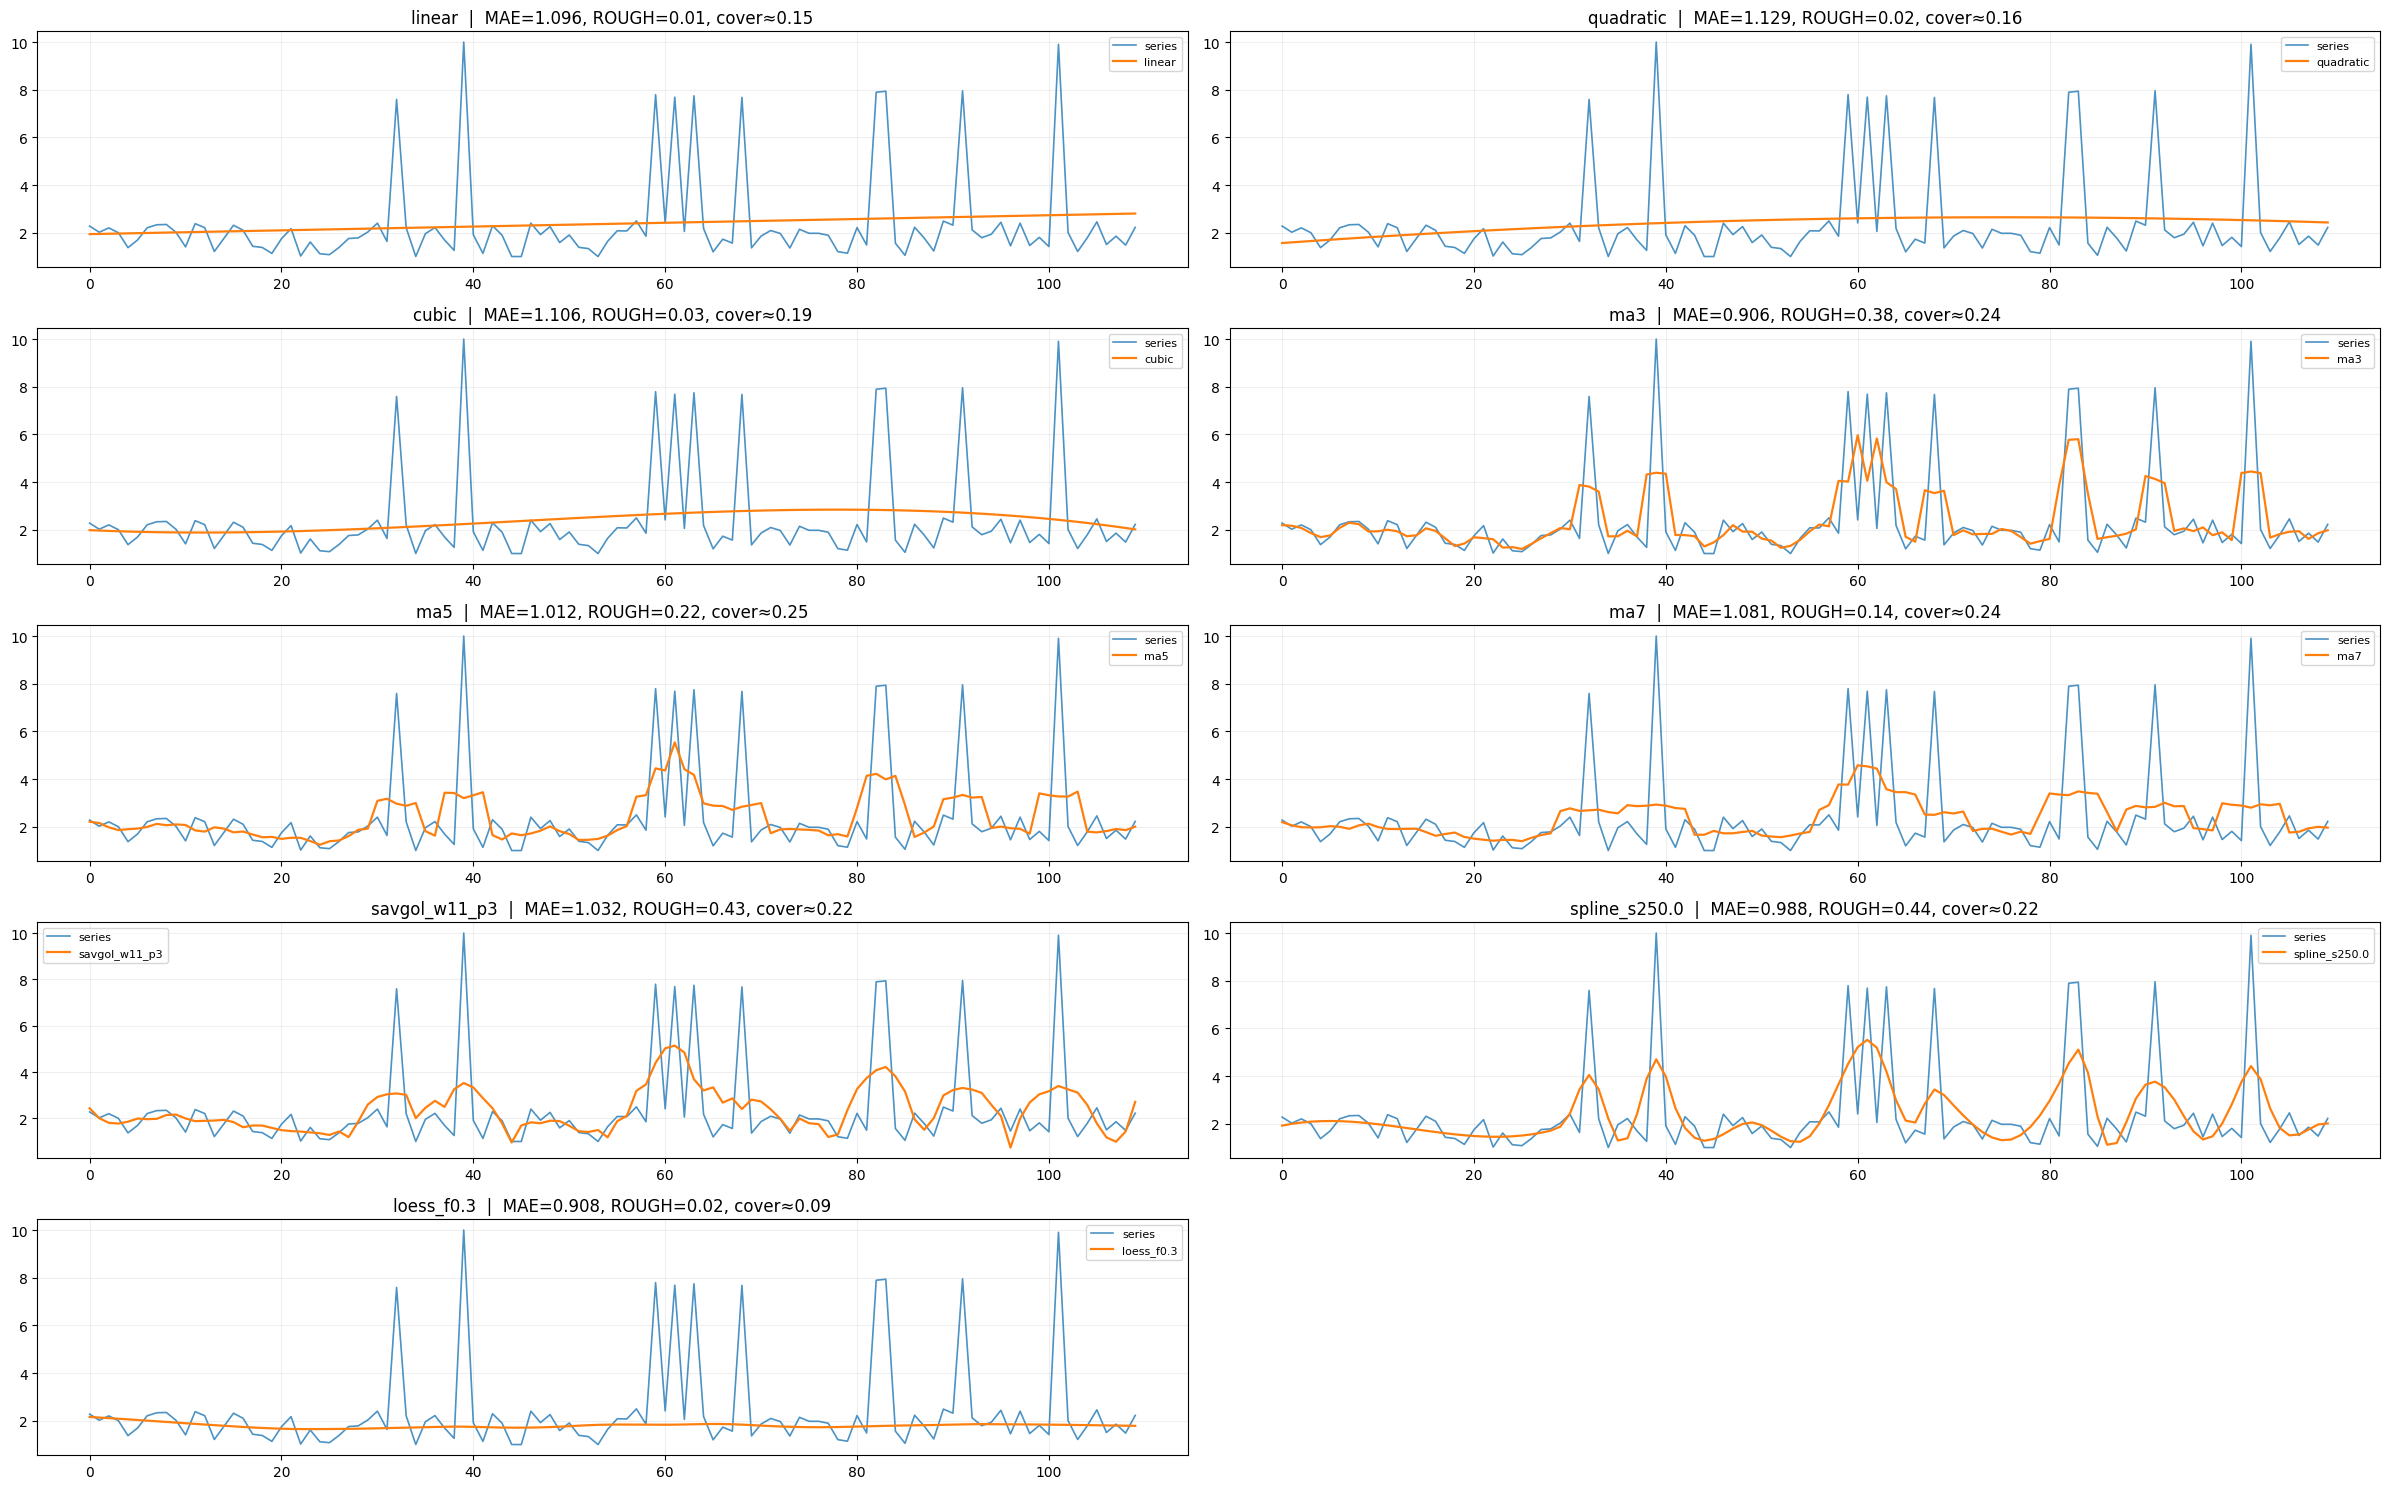

In [5]:
training.plot_model_fits_on_training(
    dataset_train_scaled,
    models_to_plot=CANDS,
    max_plots=10
)

In [6]:
alpha_mean, beta_mean, *_ = utilities.execute_batch_processing(
    batches,
    alpha_range=ALPHA_RANGE,
    selected_position=SELECTED_POS,
    model_name=GLOBAL_MODEL,
    model_params=GLOBAL_PARAMS,
)
print(f"[PARAMS] alpha_mean={alpha_mean:.4f}, beta_mean={beta_mean:.4f}")


[GLOBAL MODEL] built once: model=loess, params={'frac': 0.3}, len(L_full)=152

Processing batch 1/22...
Batch 1 best: alpha=-0.456, beta=0.544, approx_ratio=0.609913, selected_index=1, rank_in_diag=1
Batch 1 completed in 2.22 seconds.

Processing batch 2/22...
Batch 2 best: alpha=-0.633, beta=0.367, approx_ratio=0.559183, selected_index=1, rank_in_diag=1
Batch 2 completed in 2.02 seconds.

Processing batch 3/22...
Batch 3 best: alpha=-0.544, beta=0.456, approx_ratio=0.347899, selected_index=2, rank_in_diag=2
Batch 3 completed in 2.15 seconds.

Processing batch 4/22...
Batch 4 best: alpha=-0.544, beta=0.456, approx_ratio=0.668542, selected_index=2, rank_in_diag=2
Batch 4 completed in 2.09 seconds.

Processing batch 5/22...
Batch 5 best: alpha=-0.189, beta=0.811, approx_ratio=0.554684, selected_index=0, rank_in_diag=0
Batch 5 completed in 2.24 seconds.

Processing batch 6/22...
Batch 6 best: alpha=-0.278, beta=0.722, approx_ratio=0.583223, selected_index=2, rank_in_diag=0
Batch 6 complet

In [7]:
from AD_QAOA_ext import AD_QAOA
from functions.AD_utilities import build_global_model_cache
import numpy as np

# Ricostruisci la serie completa dai batch
X_full = [pt for batch in batches for pt in batch]

# Calcola L globale e la mappa per timestamp
L_full, L_by_ts, _ = build_global_model_cache(X_full, GLOBAL_MODEL, GLOBAL_PARAMS)

# Ora puoi confrontare batch per batch
for i, B in enumerate(batches, 1):
    ts_b = [t for (t,_) in B]
    # L globale ristretta al batch
    L_b_override = np.array([L_by_ts[t] for t in ts_b])

    # L calcolata localmente sul batch (vecchia logica)
    ad_tmp = AD_QAOA(X=B, alpha=0, beta=0, model_name=GLOBAL_MODEL, model_params=GLOBAL_PARAMS)
    L_b_old = ad_tmp.diag_M(B)

    diff = float(np.max(np.abs(L_b_override - L_b_old)))
    print(f"Batch {i}: max abs diff = {diff:.6g}")


Batch 1: max abs diff = 0.690287
Batch 2: max abs diff = 0.629985
Batch 3: max abs diff = 0.679657
Batch 4: max abs diff = 0.666008
Batch 5: max abs diff = 0.693315
Batch 6: max abs diff = 0.692373
Batch 7: max abs diff = 0.950728
Batch 8: max abs diff = 0.964392
Batch 9: max abs diff = 0.703631
Batch 10: max abs diff = 0.703631
Batch 11: max abs diff = 0.735305
Batch 12: max abs diff = 0.951351
Batch 13: max abs diff = 0.950822
Batch 14: max abs diff = 0.950407
Batch 15: max abs diff = 0.58128
Batch 16: max abs diff = 0.681053
Batch 17: max abs diff = 0.952612
Batch 18: max abs diff = 0.952506
Batch 19: max abs diff = 0.952506
Batch 20: max abs diff = 0.963683
Batch 21: max abs diff = 0.963683
Batch 22: max abs diff = 0.678509


In [8]:
#alpha_mean = -0.80  # per testare senza eseguire il batch processing
#beta_mean  = 0.20   # per testare senza eseguire il batch

In [9]:
unique_centers_with_radii = utilities.execute_qaoa_on_batches(
    batches,
    model_name=GLOBAL_MODEL,
    model_params=GLOBAL_PARAMS,
    alpha_mean=alpha_mean,
    beta_mean=beta_mean,
)


Initializing the final run...
[GLOBAL MODEL] built once: model=loess, params={'frac': 0.3}, len(L_full)=152

Executing QAOA model on batch 1/22...
QAOA solution for batch 1: [[0, 1, 1, 1, 0, 0, 1], [1, 0, 1, 0, 0, 0, 1], [0, 1, 1, 1, 0, 0, 0], [1, 1, 1, 0, 0, 0, 1], [1, 0, 1, 1, 0, 0, 1]]
Batch 1 - QAOA cost: -0.292689453345618, Classical optimal solution: -0.6664322096307247, Approximation ratio: 0.43918863631726257
Radius: 0.10072957316420585
Radius adjusted check_ok
Batch 1 completed. Saved centers with radii: [((1, 2.021036710995433), 1.0), ((2, 2.202621079729607), 1.0), ((3, 2.000167363811299), 1.0), ((6, 2.2075389327413255), 1.0)]

Executing QAOA model on batch 2/22...
QAOA solution for batch 2: [[0, 1, 1, 1, 0, 0, 1], [0, 0, 1, 1, 0, 0, 1], [0, 1, 0, 0, 1, 0, 0], [0, 1, 1, 1, 0, 0, 0], [0, 1, 1, 0, 1, 0, 0]]
Batch 2 - QAOA cost: -0.18626108769416871, Classical optimal solution: -0.43916216906128125, Approximation ratio: 0.4241282624418808
Radius: 0.11554430484563111
Radius adju

Anomalies detected: 36
Anomalies: [(0, 1.097856389777644), (2, 4.668831094656871), (4, 5.092332973135413), (5, 1.9180809994891914), (8, 4.961337703794849), (9, 1.0955445347174955), (10, 1.4970860867519529), (11, 1.2035912006718643), (12, 1.5983317828966666), (13, 1.924846481482526), (15, 1.7593981714229572), (18, 1.4555185455105257), (19, 1.6981594965991658), (21, 1.4651171264982517), (22, 1.060384663920457), (24, 1.9501693093937318), (25, 6.710862278636616), (26, 1.0737570607136622), (28, 6.727584310239757), (29, 1.23376283521156), (30, 1.9206279442821184), (32, 1.8588021303045326), (45, 1.02159962967872), (46, 5.983629381580277), (48, 1.291272431300599), (49, 1.1862936514576115), (51, 1.9903580996182522), (52, 6.978352487772716), (53, 1.306153482254089), (54, 1.548761242679397), (61, 5.707644065011219), (68, 1.8222497303827556), (73, 1.8024074911065662), (74, 1.9638831233729714), (79, 4.43745412025714), (109, 1.1943255232108898)]


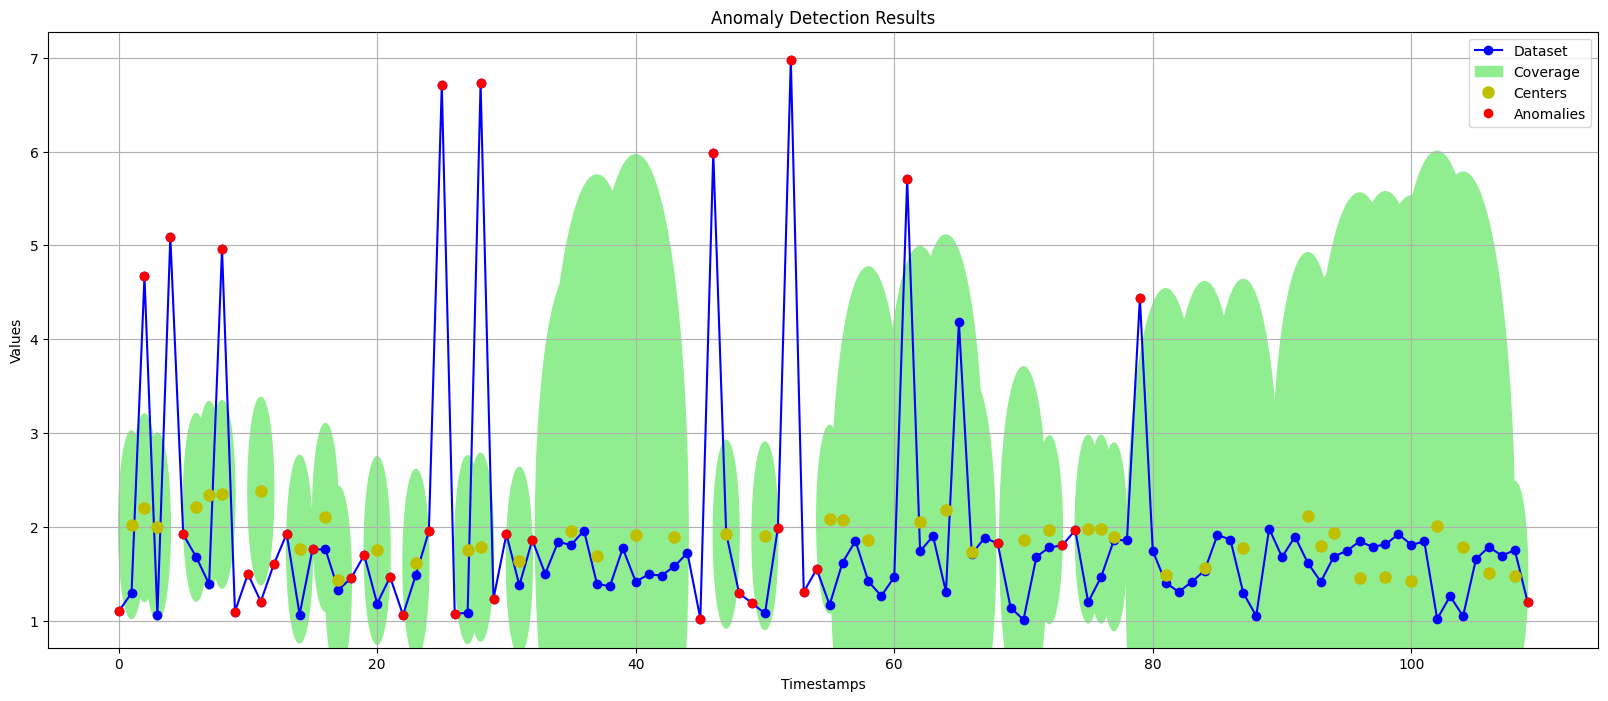

In [10]:
anomalies = detection.apply_circles_to_new_dataset(dataset_test, unique_centers_with_radii)

detection.plot_anomaly_detection_results_coverage(dataset_test, unique_centers_with_radii, anomalies, title="Anomaly Detection Results")

# detection.plot_anomaly_detection_results(dataset_test, unique_centers_with_radii, anomalies, title="Anomaly Detection Results")

## New

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.getcwd())

from AD_QAOA_ext import AD_QAOA
from functions import AD_preprocessing as preprocessing
from functions import AD_utilities as utilities
from functions import AD_training as training
from functions import AD_detection as detection

from functions.AD_probabilistic import execute_qaoa_probcover_on_batches_ml

In [2]:
# 0) Config
ALPHA_RANGE  = np.linspace(-0.9, -0.1, 10)
SELECTED_POS = 1

TOPK_STATES  = 10
#top_sel=[0,3]

TIME_SCALE   = 1.0
VALUE_SCALE  = 1.0


Batch mode: legacy
Selected overlap: 0


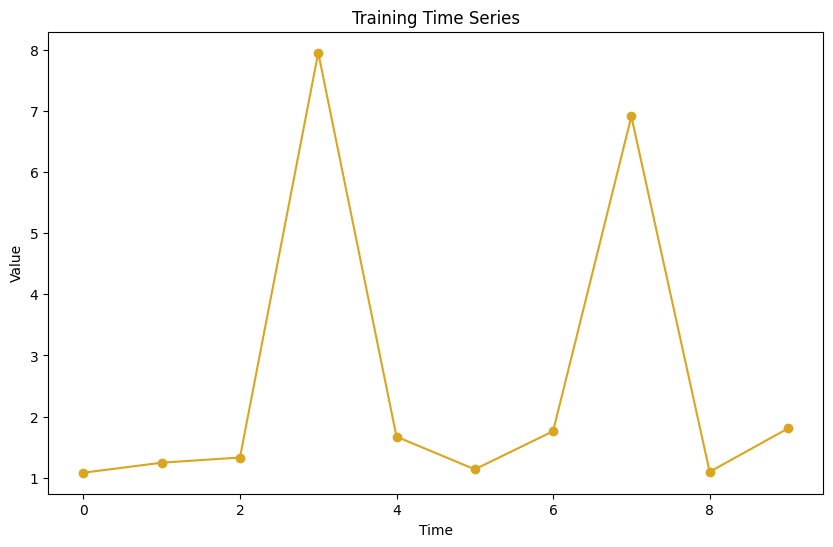


Scaling the TRAIN dataset...


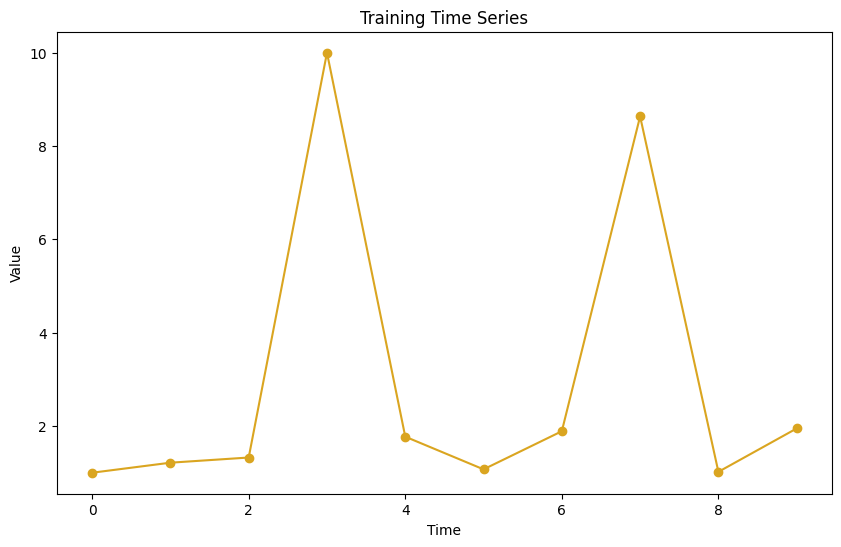

Possible batch sizes: [10]
Best batch size for balanced batches: 10
 Batch 0: size 10
[(0, 1.0), (1, 1.2149158141400456), (2, 1.325702741060156), (3, 10.0), (4, 1.7721227980755696), (5, 1.0722757108527143), (6, 1.8891551721947188), (7, 8.63497696807789), (8, 1.0190534626652623), (9, 1.948599205466599)]


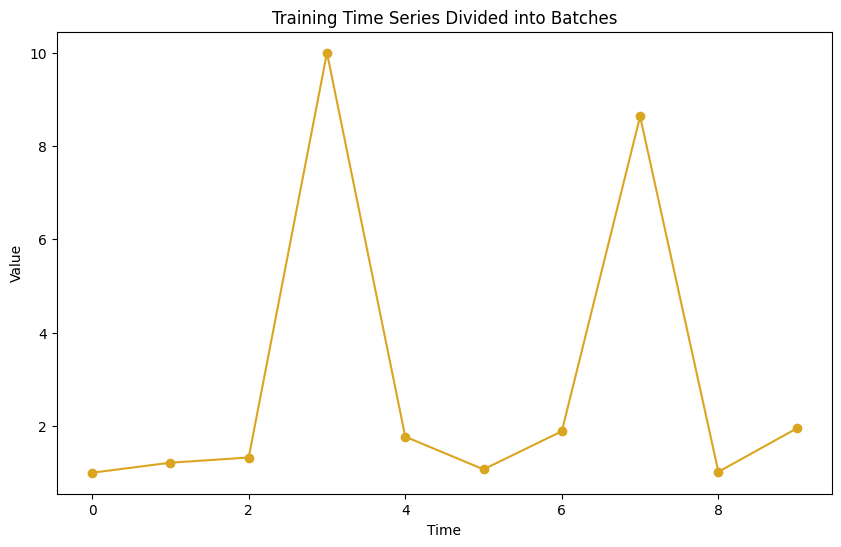


Scaling the TEST dataset...


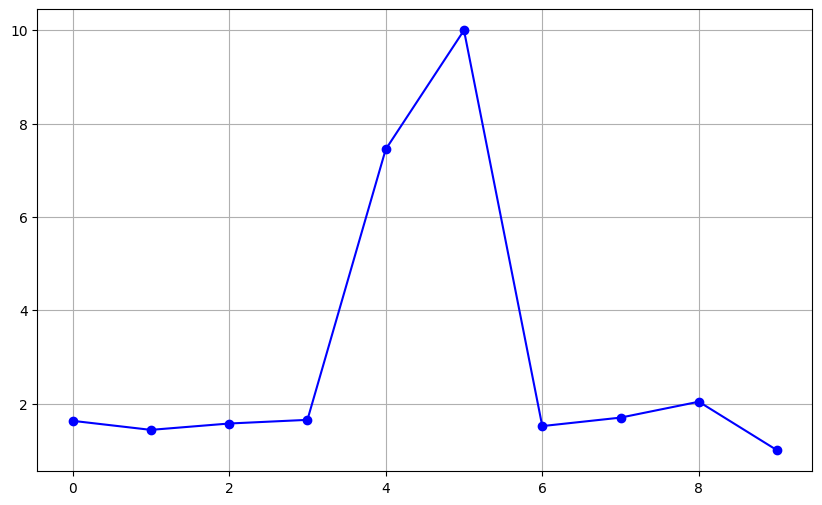

In [3]:
# === ARTIFICIAL DATASET: train/test prep, scaling, batching, plotting ===
import numpy as np
from functions import AD_preprocessing as preprocessing
from functions import AD_utilities as utilities

# 0) Config: scegli "extended" per batch grandi, "legacy" per 7/8/9
BATCH_MODE = "legacy"   # "extended" | "legacy"
overlap    = 0           # un po' più alto per batch grandi (puoi mettere 2)
print("Batch mode:", BATCH_MODE)
print("Selected overlap:", overlap)

# 1) Generate TRAIN
seed = 19  #da 42
np.random.seed(seed)

dataset_train, _ = preprocessing.generate_dataset(
    normal_sample_type='uniform',
    normal_sample_params={'low': 1, 'high': 2, 'size': 8},
    outlier_sample_type='uniform',
    outlier_sample_params={'low': 5, 'high': 8, 'size': 2} #cambiato da 5 a 8
)

utilities.plot_training_time_series(dataset_train)
# print("Train Dataset:", dataset_train)

# 2) Scaling (TRAIN)
print("\nScaling the TRAIN dataset...")
dataset_train_scaled = preprocessing.scale_dataset(dataset_train)
utilities.plot_training_time_series(dataset_train_scaled)

# 3) Batching (TRAIN)
if BATCH_MODE == "extended":
    candidate_bs = [12,14,16]
else:
    #candidate_bs = [7, 8, 9]
    candidate_bs = [11]

# Filtra i candidati che entrano nella lunghezza del train
candidate_bs = [b for b in candidate_bs if b <= len(dataset_train_scaled)]
if not candidate_bs:
    candidate_bs = [min(len(dataset_train_scaled),  max(7, 24))]

print("Possible batch sizes:", candidate_bs)

batches, best_batch_size = preprocessing.split_dataset_with_best_batch_size(
    dataset_train_scaled, overlap, candidate_bs
)
print("Best batch size for balanced batches:", best_batch_size)
for i, batch in enumerate(batches):
    print(f" Batch {i}: size {len(batch)}")
    print(batch)

utilities.plot_training_time_series_batches(
    dataset_train_scaled, overlap=overlap, batch_sizes=candidate_bs
)

# 4) Generate TEST (stessa logica)
dataset_test, _ = preprocessing.generate_dataset(
    normal_sample_type='uniform',
    normal_sample_params={'low': 1, 'high': 2, 'size': 8},
    outlier_sample_type='uniform',
    outlier_sample_params={'low': 5, 'high': 8, 'size': 2} #cambiato da 5 a 8
)

# 5) Scaling (TEST) + Plot
print("\nScaling the TEST dataset...")
dataset_test_scaled = preprocessing.scale_dataset(dataset_test)
utilities.plot_test_time_series(dataset_test_scaled)

# >>> Variabili pronte per la pipeline:
# dataset_train_scaled, dataset_test_scaled, batches, best_batch_size

In [4]:
CANDS = ("linear","quadratic","cubic","ma3","ma5","ma7",
         "savgol_w11_p3","spline_s250.0","loess_f0.3")

#CANDS = ("cubic",)
# selezione bilanciata, neutra
GLOBAL_MODEL, GLOBAL_PARAMS = training.select_global_model_for_ad(
    dataset_train_scaled,
    candidates=CANDS,
    w_acc=0.40, w_smooth=0.30, w_floor=0.15, w_cover=0.15,
    rho=1.05, gamma=2.0, target_cov=0.10,
)
print("[GLOBAL AD]", GLOBAL_MODEL, GLOBAL_PARAMS)

# tabella di debug (facoltativa)
dbg = training.debug_model_selection_for_ad(
    dataset_train_scaled, candidates=CANDS,
    w_acc=0.40, w_smooth=0.30, w_floor=0.15, w_cover=0.15,
    rho=1.05, gamma=2.0, target_cov=0.10,
)
print(dbg[dbg["model"] == "cubic,"][[
    "label","model","params","MAE","ROUGH","SIGMA_RES","COVER",
    "MAE_Z","RD","RD_Z","FLOOR","COVER_Z","J"
]].to_string(index=False))

[GLOBAL AD] loess {'frac': 0.3}
Empty DataFrame
Columns: [label, model, params, MAE, ROUGH, SIGMA_RES, COVER, MAE_Z, RD, RD_Z, FLOOR, COVER_Z, J]
Index: []


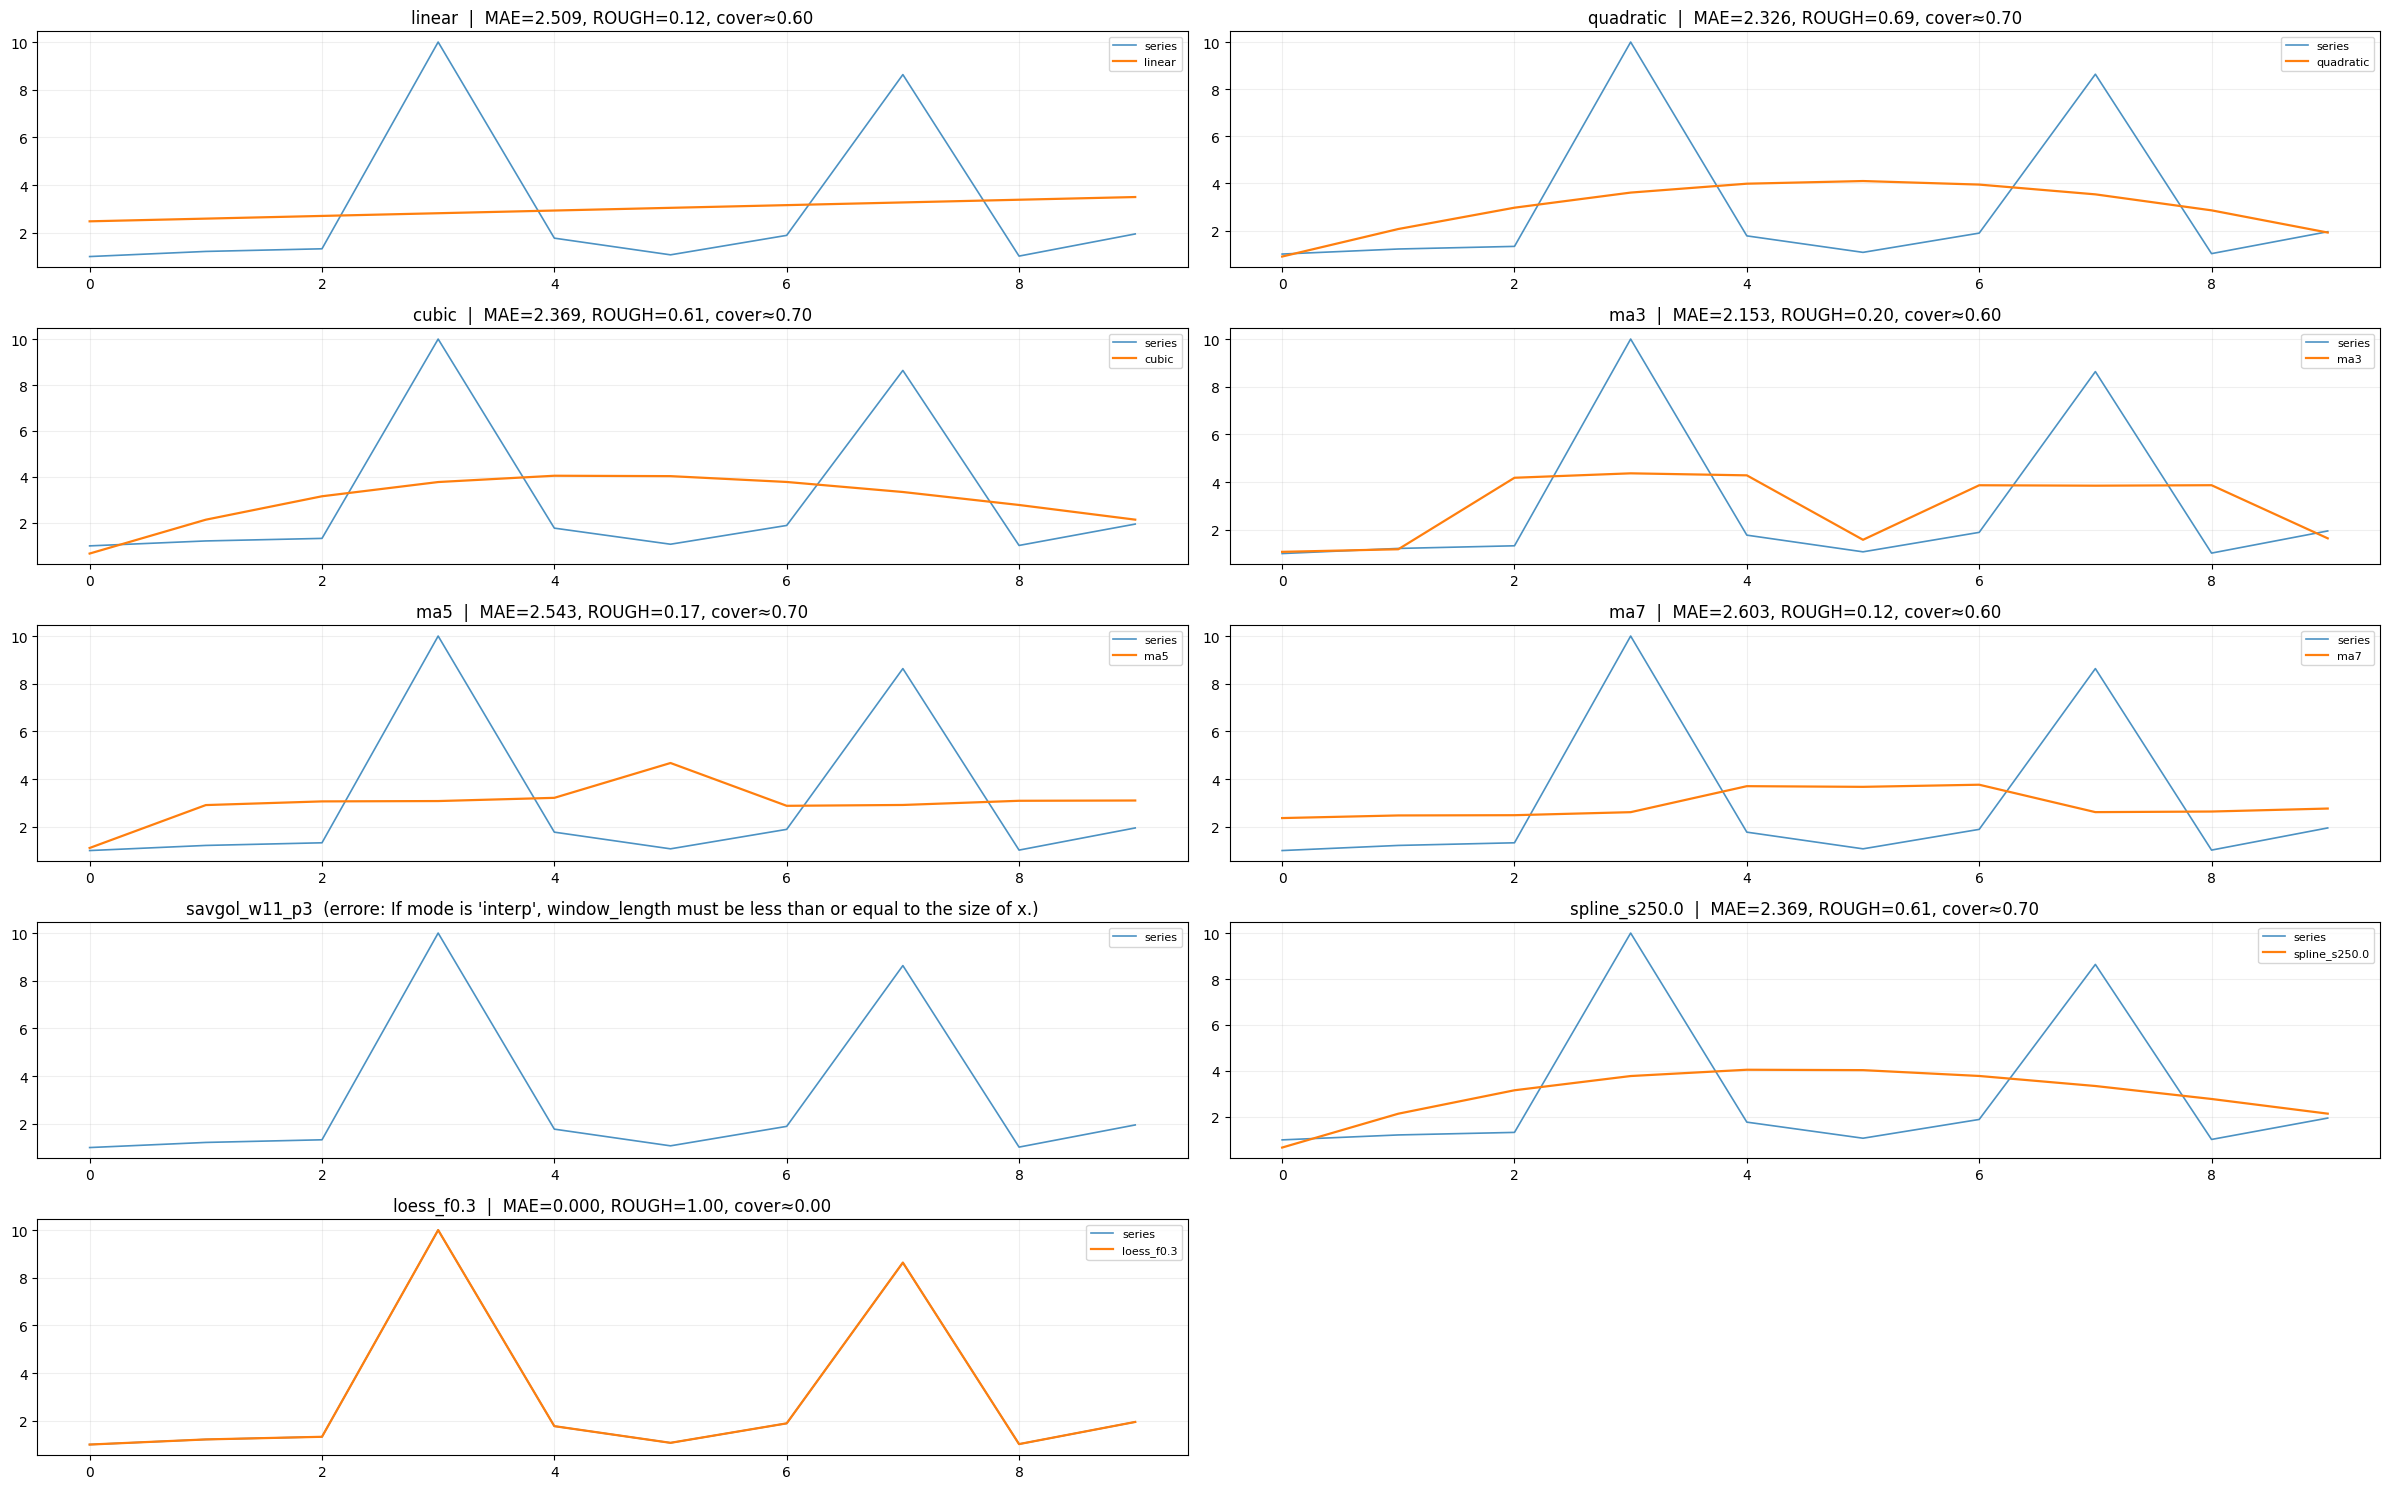

In [5]:
training.plot_model_fits_on_training(
    dataset_train_scaled,
    models_to_plot=CANDS,
    max_plots=10
)

In [6]:
alpha_mean, beta_mean, *_ = utilities.execute_batch_processing(
    batches,
    alpha_range=ALPHA_RANGE,
    selected_position=SELECTED_POS,
    model_name=GLOBAL_MODEL,
    model_params=GLOBAL_PARAMS,
)
print(f"[PARAMS] alpha_mean={alpha_mean:.4f}, beta_mean={beta_mean:.4f}")


[PARAMS] alpha_mean=-0.3667, beta_mean=0.6333


In [7]:
#alpha_mean = -0.2778  # per testare senza eseguire il batch processing
#beta_mean  = 0.7222   # per testare senza eseguire il batch

In [8]:
#unique_centers_with_radii = execute_qaoa_probcover_on_batches_ml(
#    batches=batches,
#    alpha_mean=alpha_mean,
#    beta_mean=beta_mean,
#    model_name=GLOBAL_MODEL,      # quello che già selezioni
#    model_params=GLOBAL_PARAMS,  # idem
#    top_k=5,                           # le tue top-5
#    tau=0.75,                          # soglia del selettore
#    v_strong=2,                        # voto forte (k=5)
#    w_strong=0.35,                     # soglia pesi se hai le prob
#    kappa_r=1.2,                       # guardia singleton
#    verbose=True,
#)

In [9]:
from AD_QAOA_ext import AD_QAOA
from functions.AD_probabilistic import select_centers_mask_from_topk, _ensure_2d_states, _is_singleton_for_index, topk_votes
import numpy as np

def _covered_by_circles(points, centers, radius):
    covered = 0
    for (t, v) in points:
        inside = False
        for (ct, cv) in centers:
            dt = t - ct
            dv = v - cv
            if (dt*dt + dv*dv) <= radius*radius:
                inside = True; break
        covered += int(inside)
    return covered / max(1, len(points))

def tune_selector_params(
    batches, alpha_mean, beta_mean, model_name, model_params,
    top_k=5, grid_tau=(0.6,0.7,0.75,0.8,0.85),
    grid_v=(2,3), grid_w=(0.30,0.35,0.40), grid_kappa=(1.0,1.2,1.5),
    target_cov=0.9, verbose=True
):
    best = None

    for tau in grid_tau:
        for v_strong in grid_v:
            for w_strong in grid_w:
                for kappa_r in grid_kappa:

                    centers_counts, consensus_rates, coverages, singleton_counts = [], [], [], []

                    for batch in batches:
                        ad = AD_QAOA(
                            X=batch, alpha=alpha_mean, beta=beta_mean,
                            model_name=model_name, model_params=(model_params or {}),
                            radius_adjustment=True, top_n_samples=top_k
                        )
                        # top-k
                        try:
                            top_states, _vars, topk_probs = ad.solve_qubo_extended()
                        except AttributeError:
                            st, _ = ad.solve_qubo()
                            top_states = [st] if st is not None else []
                            topk_probs = None
                        if not top_states:
                            continue
                        top_states = top_states[:top_k]
                        if topk_probs: topk_probs = topk_probs[:len(top_states)]

                        # mask con la tua funzione (nessun return_debug)
                        mask = select_centers_mask_from_topk(
                            X=batch, top_states=top_states, topk_probs=topk_probs,
                            tau=tau, v_strong=v_strong, w_strong=w_strong,
                            kappa_r=kappa_r, ad_qaoa_obj=ad
                        )

                        # centri + raggio (come nel wrapper)
                        sel_idx = [j for j, v in enumerate(mask) if v>0.5]
                        centers = [batch[j] for j in sel_idx]
                        if not centers:
                            C0_idx = [j for j,b in enumerate(top_states[0]) if b==1]
                            centers = [batch[j] for j in C0_idx]
                        radius = ad.radius_adj(centers)

                        # diagnostica ricavata da top_states
                        S = _ensure_2d_states(top_states)
                        votes, _weights = topk_votes(top_states, topk_probs)
                        single_flags = np.array([_is_singleton_for_index(S, i) for i in range(S.shape[1])], dtype=bool)

                        m = np.array(mask, dtype=int)
                        centers_counts.append(int(m.sum()))
                        if m.sum() > 0:
                            consensus_rates.append(float((votes[m==1] >= 2).mean()))
                            singleton_counts.append(int((single_flags & (m==1)).sum()))
                        else:
                            consensus_rates.append(0.0)
                            singleton_counts.append(0)

                        cov = _covered_by_circles(batch, centers, radius)
                        coverages.append(cov)

                    if len(centers_counts)==0:
                        continue
                    C = float(np.mean(centers_counts))
                    Q = float(np.mean(consensus_rates))
                    Sg = float(np.mean(singleton_counts))
                    V = float(np.mean(coverages))
                    score = C + 2.0*Q - 5.0*Sg - 3.0*abs(V - float(target_cov))

                    if verbose:
                        print(f"[TUNE] tau={tau:.2f} v_strong={v_strong} w_strong={w_strong:.2f} kappa_r={kappa_r:.1f} "
                              f"-> score={score:.3f}  C={C:.2f} Q={Q:.2f} S={Sg:.2f} V={V:.2f}")

                    if (best is None) or (score > best["score"]):
                        best = dict(score=score, C=C, Q=Q, S=Sg, V=V,
                                    tau=tau, v_strong=v_strong, w_strong=w_strong, kappa_r=kappa_r)

    if verbose and best:
        print("\n[Best params]", best)
    return best


In [10]:
#best = tune_selector_params(
#    batches=batches,
#    alpha_mean=alpha_mean, beta_mean=beta_mean,
#    model_name=GLOBAL_MODEL, model_params=GLOBAL_PARAMS,
#    top_k=5, target_cov=0.9
#)

In [11]:
best = {'tau':0.6, 'v_strong':2, 'w_strong':0.4, 'kappa_r':1.0}


In [12]:
unique_centers_with_radii = execute_qaoa_probcover_on_batches_ml(
    batches=batches,
    alpha_mean=alpha_mean, beta_mean=beta_mean,
    model_name=GLOBAL_MODEL, model_params=GLOBAL_PARAMS,
    top_k=TOPK_STATES,                  # deve contenere almeno la 3ª
    #top_sel="3",
    anomaly_ts=[1,3],       # <<— supervisionato: anomalie note
    tau=best["tau"], v_strong=best["v_strong"],
    w_strong=best["w_strong"], kappa_r=best["kappa_r"],
    verbose=True
)

[GLOBAL MODEL] built once: model=loess, params={'frac': 0.3}, len(L_full)=10

[ProbCover-ML] Batch 1/1
[Supervised] Batch 1: normals selected = 4 / 10
[ProbCover-ML] Top-10 states (batch 1):
    1100010010
    1000010010
    0000101001
    0100010010
    1100010000
    1010010010
    0110010010
    0110010000
    1110010000
    1000000010
[ProbCover-ML] Combined mask (batch 1):
    1010010010
Radius: 3.2468461118270895
Radius adjusted check_ok
[ProbCover-ML] mask len=10 | batch len=10 | #centers=4
[ProbCover-ML] Selected centers: [((0, 1.0), 3.2468461118270895), ((2, 1.325702741060156), 3.2468461118270895), ((5, 1.0722757108527143), 3.2468461118270895), ((8, 1.0190534626652623), 3.2468461118270895)]

[ProbCover-ML] Merged centers across batches:
  0: center=(0, 1.0), radius=3.2468461118270895
  1: center=(2, 1.325702741060156), radius=3.2468461118270895
  2: center=(5, 1.0722757108527143), radius=3.2468461118270895
  3: center=(8, 1.0190534626652623), radius=3.2468461118270895


In [13]:
# === QUBO COST: top1 vs mask della pipeline per combinazioni scelte =========
# g(z) = z^T M z, con M = diag(L_batch) + Q_b (stesso override della pipeline)

import numpy as np
import pandas as pd
import types

# ------- CONFIG: combinazioni da testare -----------------------------------
COMBOS = {
    "top1_only": "1",
    "top1+2":    "1,2",
    "top1..3":   "1:3",
    "top1..4":   "1:4",

    # singole solo 2, 3, 4
    "only_2":    "2",
    "only_3":    "3",
    "only_4":    "4",

    # coppie miste
    "1+3":       "1,3",
    "1+4":       "1,4",

    # triplette fino a 4
    "1,2,3":     "1,2,3",
    "1,2,4":     "1,2,4",
    "1,3,4":     "1,3,4",
    "2,3,4":     "2,3,4",
}

# Se vuoi limitarti a batch piccoli:
MAX_N_PER_BATCH = 10   # None per non filtrare

# ------- Utility leggere ---------------------------------------------------
def _state_to_bits(s, n: int) -> str:
    try:
        import numpy as _np
    except Exception:
        _np = None
    if isinstance(s, (list, tuple)) and len(s) > 0 and not isinstance(s[0], (int, str)):
        s = s[0]
    if isinstance(s, str):
        if len(s) < n:  s = s.rjust(n, '0')
        elif len(s) > n: s = s[-n:]
        return s
    if (_np is not None and isinstance(s, _np.ndarray)) or isinstance(s, (list, tuple)):
        seq = s.tolist() if (_np is not None and hasattr(s, 'tolist')) else s
        return ''.join('1' if int(x) else '0' for x in seq)
    if isinstance(s, int) or (_np is not None and isinstance(s, _np.integer)):
        return format(int(s), f'0{n}b')[-n:]
    s = str(s)
    if len(s) < n:  s = s.rjust(n, '0')
    elif len(s) > n: s = s[-n:]
    return s

def _vec_from_bits(bits: str) -> np.ndarray:
    return np.fromiter((1 if c == '1' else '0' for c in bits), dtype=float)

def _parse_top_sel_indices(n_states: int, sel_str: str):
    idx = []
    parts = [p.strip() for p in sel_str.split(',')] if sel_str else []
    for p in parts:
        if not p:
            continue
        if ':' in p:
            a, b = p.split(':', 1)
            a, b = int(a), int(b)
            lo, hi = (a, b) if a <= b else (b, a)
            idx.extend(range(lo-1, hi))  # 0-based
        else:
            idx.append(int(p)-1)
    idx = sorted({i for i in idx if 0 <= i < n_states})
    return idx

def _qubo_cost(M: np.ndarray, z01: np.ndarray) -> float:
    return float(z01 @ (M @ z01))

# ------- Hook solver + M override (coerente con la pipeline) ----------------
from AD_QAOA_ext import AD_QAOA
from functions.AD_utilities import build_global_model_cache

# Precompute L globale come in pipeline
X_full = [pt for batch in batches for pt in batch]
try:
    L_full, L_by_ts, _ = build_global_model_cache(X_full, GLOBAL_MODEL, GLOBAL_PARAMS or {})
    print(f"[GLOBAL MODEL] built once: len(L_full)={len(L_full)}")
except Exception as e:
    L_by_ts = None
    print(f"[GLOBAL MODEL] WARNING: fallback per-batch (err: {e})")

def _get_top_states_probs_and_M(batch, alpha_mean, beta_mean, model_name, model_params, want_k, L_by_ts):
    ad = AD_QAOA(
        X=batch,
        alpha=alpha_mean, beta=beta_mean,
        model_name=model_name, model_params=(model_params or {}),
        radius_adjustment=True,
        top_n_samples=want_k,
    )
    M = None
    if L_by_ts is not None:
        ts_b = [t for (t, _) in batch]
        L_b = np.array([L_by_ts[t] for t in ts_b], dtype=float)
        Q_b = ad.off_diag_M(batch)
        M = np.diag(L_b) + Q_b
        def _matrix_M_override(self):
            return M
        ad.matrix_M = types.MethodType(_matrix_M_override, ad)

    try:
        top_states, _vars, topk_probs = ad.solve_qubo_extended()
    except AttributeError:
        top_states = []
        st, _ = ad.solve_qubo()
        if st is not None:
            top_states.append(st)
        topk_probs = None

    if M is None:
        M = ad.matrix_M()
    return top_states, topk_probs, ad, M

def _mask_from_states(batch, states_sel, probs_sel, ad_obj,
                      tau, v_strong, w_strong, kappa_r):
    mask = select_centers_mask_from_topk(
        X=batch,
        top_states=states_sel,
        topk_probs=probs_sel,
        tau=tau,
        v_strong=v_strong,
        w_strong=w_strong,
        kappa_r=kappa_r,
        ad_qaoa_obj=ad_obj,
    )
    return np.asarray(mask, float)

# ------- Parametri ML dall'ambiente ----------------------------------------
def _get_param(name, default):
    if name in globals() and not isinstance(globals()[name], dict):
        return globals()[name]
    for dname in ('best_params', 'best'):
        if dname in globals() and isinstance(globals()[dname], dict) and name in globals()[dname]:
            return globals()[dname][name]
    return default

TAU      = float(_get_param('tau',      0.75))
V_STRONG = int(_get_param('v_strong',   2))
W_STRONG = float(_get_param('w_strong', 0.35))
KAPPA_R  = float(_get_param('kappa_r',  1.2))

# ===================== RUN ================================================
rows = []

# massimo K richiesto dai COMBOS
def _needed_k_from_sel(sel_str: str) -> int:
    idx = _parse_top_sel_indices(9999, sel_str)
    return (max(idx) + 1) if idx else 1

max_needed_k = max(_needed_k_from_sel(v) for v in COMBOS.values())

for b_idx, batch in enumerate(batches, 1):
    if MAX_N_PER_BATCH is not None and len(batch) > MAX_N_PER_BATCH:
        continue

    top_states, topk_probs, ad, M = _get_top_states_probs_and_M(
        batch, alpha_mean, beta_mean, GLOBAL_MODEL, GLOBAL_PARAMS,
        want_k=max_needed_k, L_by_ts=L_by_ts
    )
    if not top_states:
        print(f"[Batch {b_idx}] no states, skip")
        continue

    n = len(batch)

    # costo QUBO per la top1 (bitstring migliore)
    top1_bits = _state_to_bits(top_states[0], n)
    cost_top1 = _qubo_cost(M, _vec_from_bits(top1_bits))

    for label, sel_str in COMBOS.items():
        sel_idx = _parse_top_sel_indices(len(top_states), sel_str)
        if not sel_idx:
            print(f"[Batch {b_idx}] combo '{label}' non valida (no indici).")
            continue
        states_sel = [top_states[i] for i in sel_idx]
        probs_sel  = [topk_probs[i] for i in sel_idx] if topk_probs is not None else None

        mask = _mask_from_states(batch, states_sel, probs_sel, ad,
                                 tau=TAU, v_strong=V_STRONG,
                                 w_strong=W_STRONG, kappa_r=KAPPA_R)
        cost_mask = _qubo_cost(M, mask)

        # bitstring della mask finale
        mask_bits = ''.join('1' if x > 0.5 else '0' for x in mask.astype(int))

        rows.append({
            "batch": b_idx,
            "n": n,
            "combo": label,
            "sel_indices_1based": [i+1 for i in sel_idx],
            "top1_bits": top1_bits,
            "mask_bits": mask_bits,
            "cost_top1": cost_top1,
            "cost_mask": cost_mask,
        })

df_cost = pd.DataFrame(rows)
print("\n=== QUBO cost (top1 vs mask) ===")
if not df_cost.empty:
    print(df_cost.to_string(index=False))
else:
    print("Nessun risultato (controlla COMBOS o filtri).")


[GLOBAL MODEL] built once: len(L_full)=10

=== QUBO cost (top1 vs mask) ===
 batch  n     combo sel_indices_1based  top1_bits  mask_bits  cost_top1  cost_mask
     1 10 top1_only                [1] 0000101001 0000101001   3.705906   3.705906
     1 10    top1+2             [1, 2] 0000101001 0000101001   3.705906   3.705906
     1 10   top1..3          [1, 2, 3] 0000101001 1110111011   3.705906  34.402062
     1 10   top1..4       [1, 2, 3, 4] 0000101001 1110111011   3.705906  34.402062
     1 10    only_2                [2] 0000101001 1100000010   3.705906   3.859663
     1 10    only_3                [3] 0000101001 0110010000   3.705906   4.013708
     1 10    only_4                [4] 0000101001 1110010010   3.705906   8.389071
     1 10       1+3             [1, 3] 0000101001 0000101001   3.705906   3.705906
     1 10       1+4             [1, 4] 0000101001 0110111011   3.705906  26.918413
     1 10     1,2,3          [1, 2, 3] 0000101001 1110111011   3.705906  34.402062
     1 10  

Anomalies detected: 2
Anomalies: [(4, 5.430185190804026), (5, 7.111331528765679)]


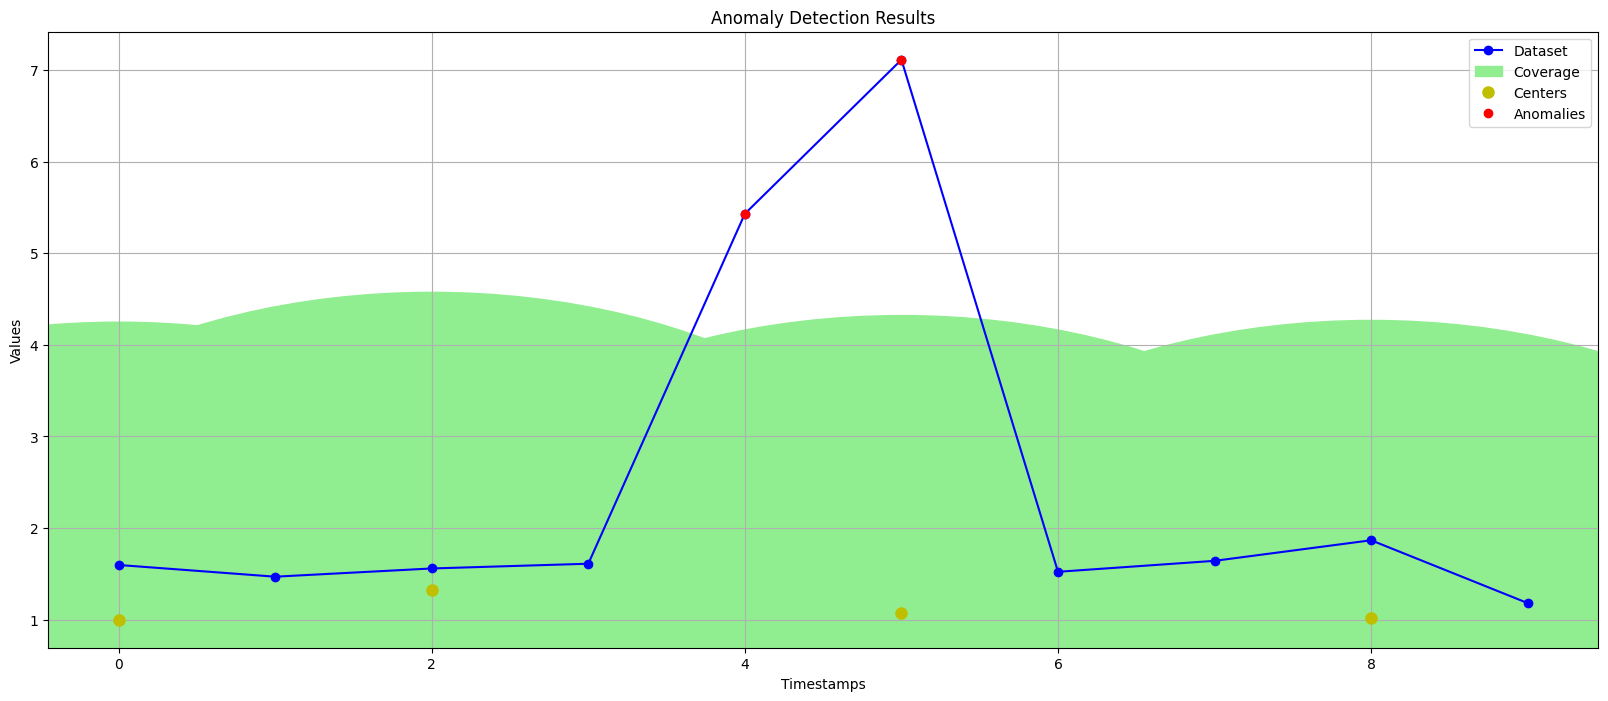

In [14]:
anomalies = detection.apply_circles_to_new_dataset(dataset_test, unique_centers_with_radii)

detection.plot_anomaly_detection_results_coverage(dataset_test, unique_centers_with_radii, anomalies, title="Anomaly Detection Results")

# detection.plot_anomaly_detection_results(dataset_test, unique_centers_with_radii, anomalies, title="Anomaly Detection Results")

Anomalies detected: 2 / 10
Anomaly list: [(4, 5.430185190804026), (5, 7.111331528765679)]
[Elliptical covering results]
 0: center=(0, 1.000), rx=4.870, ry=1.136
 1: center=(2, 1.326), rx=4.870, ry=1.136
 2: center=(5, 1.072), rx=4.870, ry=1.136
 3: center=(8, 1.019), rx=4.870, ry=1.136
Anomalies detected: 2 / 10


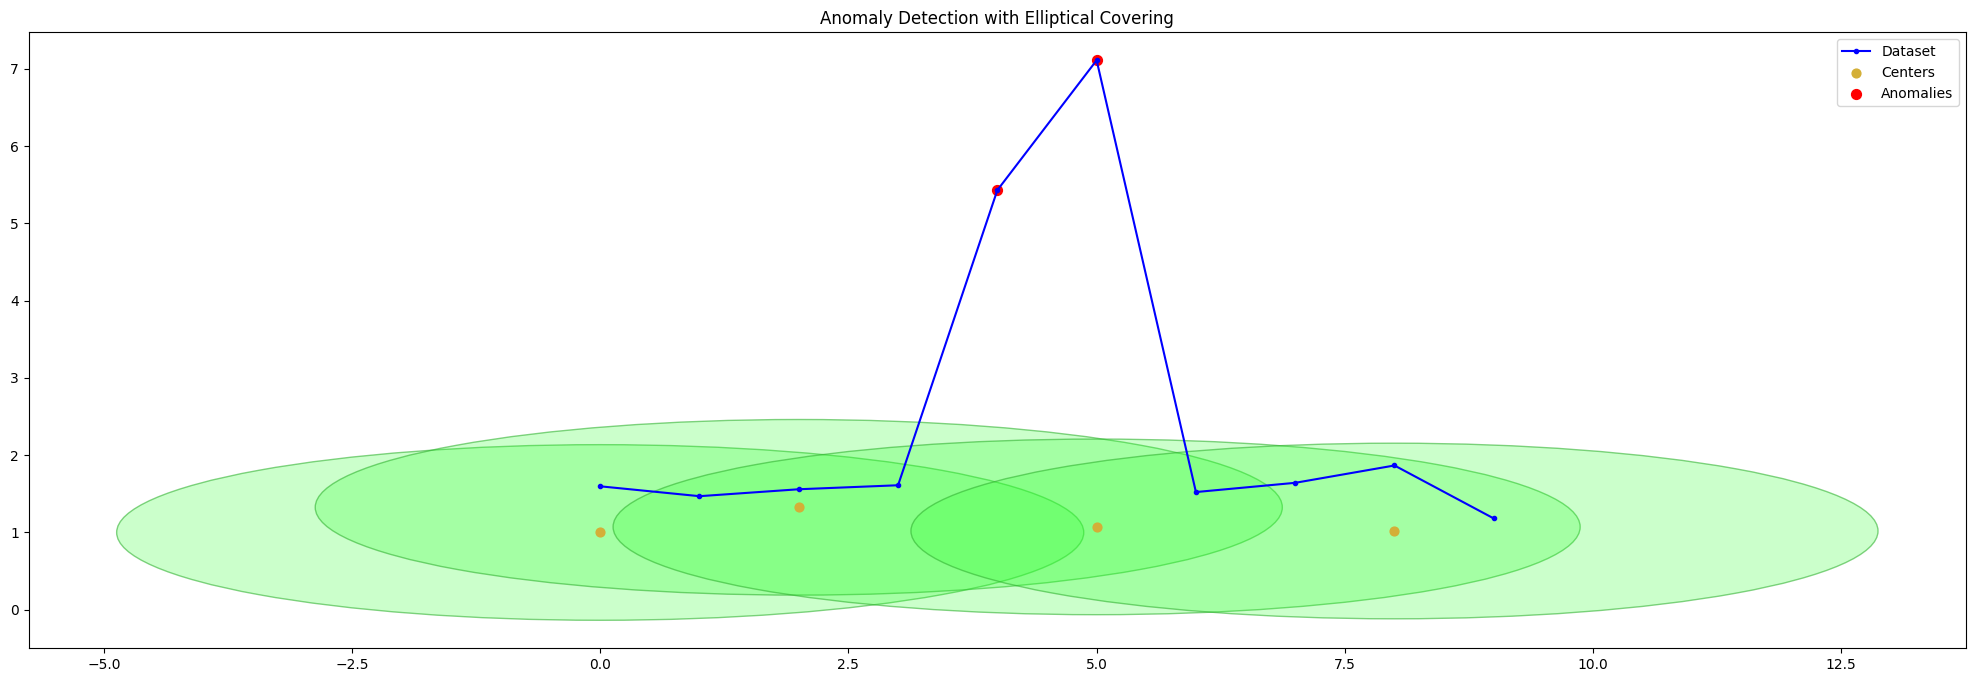

In [15]:
from functions.AD_probabilistic import to_ellipses, apply_ellipses_to_new_dataset, plot_elliptical_covering


ellipses = to_ellipses(unique_centers_with_radii, eta=0.35, xi=1.5, only_if_r_gt=1)

covered = apply_ellipses_to_new_dataset(dataset_test, ellipses, tol=0.1)
anomalies = [pt for pt, cov in zip(dataset_test, covered) if not cov]
print("Anomaly list:", anomalies)

print("[Elliptical covering results]")
for idx, ((cx, cy), rx, ry) in enumerate(ellipses):
    print(f"{idx:2d}: center=({cx}, {cy:.3f}), rx={rx:.3f}, ry={ry:.3f}")






fig, ax = plt.subplots(figsize=(25,8))

# serie originale
ax.plot([t for t,_ in dataset_test], [v for _,v in dataset_test],
        'b.-', label='Dataset')

# disegna le ellissi
plot_elliptical_covering(ax, ellipses)

# centri
ax.scatter([cx for (cx,_),_,_ in ellipses],
           [cy for (_,cy),_,_ in ellipses],
           s=40, c='#d4af37', label='Centers')

# anomalie: ricava indici da covered
covered = apply_ellipses_to_new_dataset(dataset_test, ellipses, tol=0.1)
anomalies_idx = [i for i, c in enumerate(covered) if not c]

ax.scatter([dataset_test[i][0] for i in anomalies_idx],
           [dataset_test[i][1] for i in anomalies_idx],
           s=50, c='r', label='Anomalies')

ax.legend()
ax.set_title('Anomaly Detection with Elliptical Covering')
plt.show()

## Qubit testing

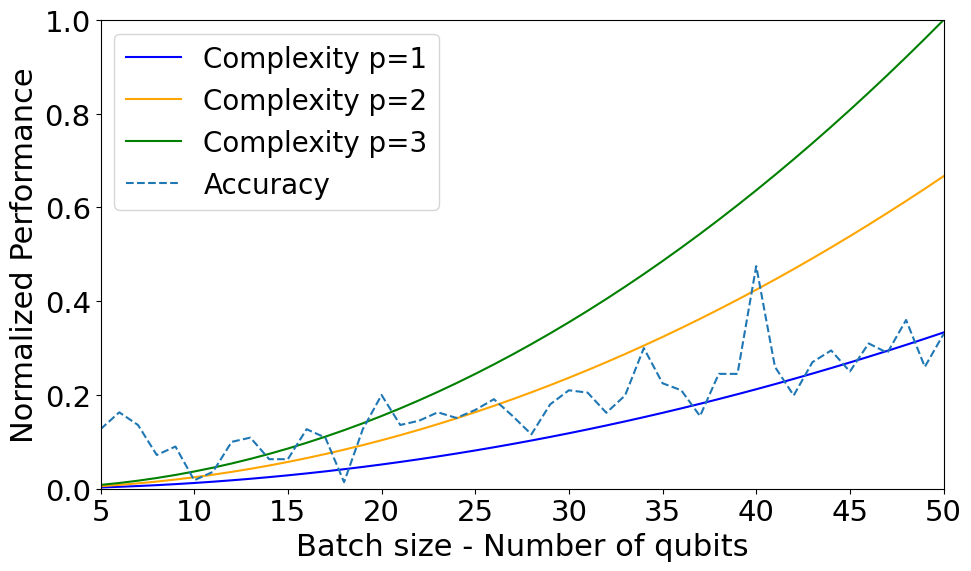

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16})

n_range = np.arange(5, 51)  # 5,6,...,50

def entangling_per_circuit(n, p):
    return p * (n * (n - 1) // 2)

complexity_p1 = [entangling_per_circuit(n, 1) for n in n_range]
complexity_p2 = [entangling_per_circuit(n, 2) for n in n_range]
complexity_p3 = [entangling_per_circuit(n, 3) for n in n_range]

max_val = max(complexity_p3)
norm_p1 = np.array(complexity_p1) / max_val
norm_p2 = np.array(complexity_p2) / max_val
norm_p3 = np.array(complexity_p3) / max_val

accuracy_vals = [
    (5, 0.127),
    (6, 0.163),
    (7, 0.136),
    (8, 0.072),
    (9, 0.090),
    (10, 0.018),
    (11, 0.036),
    (12, 0.100),
    (13, 0.109),
    (14, 0.063),
    (15, 0.063),
    (16, 0.127),
    (17, 0.109),
    (18, 0.014),
    (19, 0.127),
    (20, 0.200),
    (21, 0.136),
    (22, 0.145),
    (23, 0.163),
    (24, 0.151),
    ############################################################################
    (25, 0.168),
    (26, 0.191),
    (27, 0.155),
    (28, 0.116),
    (29, 0.180),
    #######################
    (30, 0.210),
    (31, 0.205),
    (32, 0.162),
    (33, 0.199),
    (34, 0.300),
    (35, 0.225),
    (36, 0.210),
    ###########################
    (37, 0.155),
    (38, 0.245),
    ############################
    (39, 0.245),
    (40, 0.475),
    (41, 0.260),
    (42, 0.199),
    (43, 0.270),
    ############################
    (44, 0.295),
    (45, 0.250),
    (46, 0.310),
    (47, 0.290),
    (48, 0.360),
    (49, 0.260),
    (50, 0.330),
]

acc_rows = sorted(accuracy_vals, key=lambda x: x[0])
acc_x = np.array([r[0] for r in acc_rows], dtype=int)      # batch sizes
acc_y = np.array([r[1] for r in acc_rows], dtype=float)    # accuracy

plt.figure(figsize=(10, 6))
plt.plot(n_range, norm_p1, label="Complexity p=1", color="blue")
plt.plot(n_range, norm_p2, label="Complexity p=2", color="orange")
plt.plot(n_range, norm_p3, label="Complexity p=3", color="green")

plt.plot(acc_x, acc_y, linestyle="--", linewidth=1.5, label="Accuracy", zorder=2)

plt.xlabel("Batch size - Number of qubits", fontsize=22)
plt.ylabel("Normalized Performance", fontsize=22)
plt.ylim(0.0, 1.0)
plt.xticks(fontsize=21)
plt.yticks(fontsize=21)
plt.xlim(min(n_range), max(n_range))
plt.grid(False)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
# === ENTROPY TEST v2b: pipeline vs mixed (best in pos 1..K, random Bernoulli) ===

import math
import numpy as np
import pandas as pd

# --- CONFIG ---
K_LIST       = [5,10,15,20]     # K da testare
BEST_POS_LIST = [1]         
N_TRIALS     = 1000            
RANDOM_SEED  = 123
P_RAND       = 0.5           

USE_SUPERVISED_LABELS = False
ANOMALY_TS = []              # usate solo se USE_SUPERVISED_LABELS=True

if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)

def _get_param(name, default):
    if name in globals() and not isinstance(globals()[name], dict):
        return globals()[name]
    for dname in ('best_params', 'best'):
        if dname in globals() and isinstance(globals()[dname], dict) and (name in globals()[dname]):
            return globals()[dname][name]
    return default

TAU       = float(_get_param('tau',       0.75))
V_STRONG  = int(_get_param('v_strong',    2))
W_STRONG  = float(_get_param('w_strong',  0.35))
KAPPA_R   = float(_get_param('kappa_r',   1.2))

def _state_to_bits(s, n: int) -> str:
    try:
        import numpy as _np
    except Exception:
        _np = None
    if isinstance(s, (list, tuple)) and len(s) > 0 and not isinstance(s[0], (int, str)):
        s = s[0]
    if isinstance(s, str):
        if len(s) < n:  s = s.rjust(n, '0')
        elif len(s) > n: s = s[-n:]
        return s
    if (_np is not None and isinstance(s, _np.ndarray)) or isinstance(s, (list, tuple)):
        seq = s.tolist() if (_np is not None and hasattr(s, 'tolist')) else s
        return ''.join('1' if int(x) else '0' for x in seq)
    if isinstance(s, int) or (_np is not None and isinstance(s, _np.integer)):
        return format(int(s), f'0{n}b')[-n:]
    s = str(s)
    if len(s) < n:  s = s.rjust(n, '0')
    elif len(s) > n: s = s[-n:]
    return s

def shannon_entropy(mask01):
    m = np.asarray(mask01, dtype=float)
    if m.size == 0:
        return 0.0
    p = m.mean()
    if p <= 0.0 or p >= 1.0:
        return 0.0
    return -(p*math.log2(p) + (1-p)*math.log2(1-p))

from AD_QAOA_ext import AD_QAOA
from functions.AD_utilities import build_global_model_cache

def get_top_states_for_batch(batch, alpha_mean, beta_mean, model_name, model_params, top_k, L_by_ts=None):
    ad = AD_QAOA(
        X=batch,
        alpha=alpha_mean, beta=beta_mean,
        model_name=model_name, model_params=(model_params or {}),
        radius_adjustment=True,
        top_n_samples=top_k,
    )
    M_override = None
    if L_by_ts is not None:
        try:
            ts_b = [t for (t, _) in batch]
            L_b = np.array([L_by_ts[t] for t in ts_b], dtype=float)
            Q_b = ad.off_diag_M(batch)
            M_override = np.diag(L_b) + Q_b
            import types
            def _matrix_M_override(self):
                return M_override
            ad.matrix_M = types.MethodType(_matrix_M_override, ad)
        except Exception:
            pass
    try:
        top_states, _vars, topk_probs = ad.solve_qubo_extended()
    except AttributeError:
        top_states = []
        st, _ = ad.solve_qubo()
        if st is not None:
            top_states.append(st)
        topk_probs = None
    return top_states, topk_probs, ad

def final_mask_from_states(batch, top_states_sel, topk_probs_sel, tau, v_strong, w_strong, kappa_r, ad_qaoa_obj,
                           use_supervised=False, anomaly_ts=None):
    if not use_supervised:
        mask = select_centers_mask_from_topk(
            X=batch,
            top_states=top_states_sel,
            topk_probs=topk_probs_sel,
            tau=tau,
            v_strong=v_strong,
            w_strong=w_strong,
            kappa_r=kappa_r,
            ad_qaoa_obj=ad_qaoa_obj,
        )
        return np.asarray(mask, float)
    # supervised
    anomaly_set = set(anomaly_ts or [])
    B = len(top_states_sel)
    occ = np.zeros(len(batch), dtype=int)
    for s in top_states_sel:
        bits = _state_to_bits(s, n=len(batch))
        for j, ch in enumerate(bits):
            if ch == '1':
                occ[j] += 1
    freq = occ / max(1, B)
    mask = np.zeros(len(batch), dtype=float)
    for j, (ts, _v) in enumerate(batch):
        if ts in anomaly_set:
            mask[j] = 0.0
        elif (occ[j] >= int(v_strong)) or (freq[j] >= float(tau)):
            mask[j] = 1.0
    return mask

X_full = [pt for batch in batches for pt in batch]
try:
    L_full, L_by_ts, _ = build_global_model_cache(X_full, GLOBAL_MODEL, GLOBAL_PARAMS or {})
    print(f"[GLOBAL MODEL] built once: len(L_full)={len(L_full)}")
except Exception as e:
    L_by_ts = None
    print(f"[GLOBAL MODEL] WARNING: fallback per-batch (err: {e})")

rows = []
for b_idx, batch in enumerate(batches, 1):
    top_states, topk_probs, ad = get_top_states_for_batch(
        batch, alpha_mean, beta_mean, GLOBAL_MODEL, GLOBAL_PARAMS, top_k=max(K_LIST), L_by_ts=L_by_ts
    )
    if not top_states:
        print(f"[Batch {b_idx}] no states, skip")
        continue

    n = len(batch)
    best_state = top_states[0]

    for K in K_LIST:
        top_states_sel = top_states[:K]
        probs_sel = topk_probs[:K] if topk_probs is not None else None
        mask_pipe = final_mask_from_states(
            batch, top_states_sel, probs_sel,
            tau=TAU, v_strong=V_STRONG, w_strong=W_STRONG, kappa_r=KAPPA_R,
            ad_qaoa_obj=ad,
            use_supervised=USE_SUPERVISED_LABELS,
            anomaly_ts=ANOMALY_TS
        )
        H_pipe = shannon_entropy(mask_pipe)

        pos_list = list(range(1, K+1)) if BEST_POS_LIST is None else [p for p in BEST_POS_LIST if 1 <= p <= K]
        for pos in pos_list:
            H_trials = []
            for _ in range(N_TRIALS):
                rand_list = [(np.random.rand(n) < P_RAND).astype(int).tolist() for __ in range(max(0, K-1))]
                mixed_sel = []
                inserted = False
                r_iter = iter(rand_list)
                for k_idx in range(1, K+1):
                    if k_idx == pos:
                        mixed_sel.append(best_state)
                        inserted = True
                    else:
                        mixed_sel.append(next(r_iter))
                if not inserted:  # safety
                    mixed_sel.append(best_state)

                mask_mixed = final_mask_from_states(
                    batch, mixed_sel, None,
                    tau=TAU, v_strong=V_STRONG, w_strong=W_STRONG, kappa_r=KAPPA_R,
                    ad_qaoa_obj=ad,
                    use_supervised=USE_SUPERVISED_LABELS,
                    anomaly_ts=ANOMALY_TS
                )
                H_trials.append(shannon_entropy(mask_mixed))

            rows.append({
                "batch": b_idx,
                "K": K,
                "best_pos": pos,
                "H_pipeline": H_pipe,
                "H_mixed_mean": float(np.mean(H_trials)),
                "H_mixed_std": float(np.std(H_trials)),
                "n": n,
            })

df_ent = pd.DataFrame(rows)
if not df_ent.empty:
    summary_K = df_ent.groupby("K")[["H_pipeline","H_mixed_mean"]].mean().rename(columns={
        "H_pipeline": "H_pipeline_avg", "H_mixed_mean": "H_mixed_avg"
    })
    print("\n=== Entropy summary by K (averaged over best positions) ===")
    print(summary_K)

    summary_Kpos = df_ent.groupby(["K","best_pos"])[["H_pipeline","H_mixed_mean"]].mean().rename(columns={
        "H_pipeline": "H_pipe_avg", "H_mixed_mean": "H_mix_avg"
    })
    print("\n=== Entropy by K and best position ===")
    print(summary_Kpos)

    print("\n=== Full per-batch results ===")
    print(df_ent.to_string(index=False))
else:
    print("No results (empty df).")


[GLOBAL MODEL] built once: len(L_full)=43

=== Entropy summary by K (averaged over best positions) ===
    H_pipeline_avg  H_mixed_avg
K                              
5         0.989906     0.725132
10        0.707339     0.832427
15        0.807991     0.838755
20        0.609776     0.838712

=== Entropy by K and best position ===
             H_pipe_avg  H_mix_avg
K  best_pos                       
5  1           0.989906   0.725132
10 1           0.707339   0.832427
15 1           0.807991   0.838755
20 1           0.609776   0.838712

=== Full per-batch results ===
 batch  K  best_pos  H_pipeline  H_mixed_mean  H_mixed_std  n
     1  5         1    0.991076      0.844763 3.131048e-01  9
     1 10         1    0.764205      0.986121 6.990424e-02  9
     1 15         1    0.764205      0.991076 2.220446e-16  9
     1 20         1    0.000000      0.990588 1.541844e-02  9
     2  5         1    0.991076      0.758636 2.744081e-01  9
     2 10         1    0.918296      0.910142 7.778